# ChainGuard - Demo

**A Multi-Agent, Explainable and Blockchain-Audited Cryptocurrency Crash Early-Warning System**

> Neural networks predict patterns. Agents investigate and reason over evidence.
> Blockchain makes predictions auditable.

This notebook runs top to bottom against the **frozen dataset**. Every number below
is computed by the pipeline - nothing is hardcoded (Rule 12.2).

Prerequisites: `bolt build`, `bolt train`, `bolt evaluate --all --report` and
`bolt explain --model xgb --consistency` have been run.


## 0. Setup and dataset integrity

The first thing a panel should see: the dataset we are about to use is *the same
one* the reported results came from. The data card records a SHA-256; recompute it.


In [1]:
import hashlib, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from bolt.config import load_config
from bolt.align.build import content_digest
from bolt.logging_setup import setup_logging
setup_logging({'level': 'ERROR'})

cfg = load_config('../config/default.yaml', repo_root='..')
panel_path = cfg.path('processed') / 'panel.parquet'
panel = pd.read_parquet(panel_path)

# Two digests, each checked against its OWN line in the card. Comparing
# the file hash to the content hash would report a mismatch that is not
# one - which is exactly what this cell used to do.
card = (cfg.path('processed') / 'DATA_CARD.md').read_text(encoding='utf-8')
def carded(label):
    line = next(ln for ln in card.splitlines() if ln.startswith(f'- **{label}'))
    return line.split(chr(96))[1]

checks = {
    'content': (content_digest(panel), carded('Content SHA-256')),
    'file': (hashlib.sha256(panel_path.read_bytes()).hexdigest(),
             carded('File SHA-256')),
}
for name, (computed, recorded) in checks.items():
    mark = 'MATCH' if computed == recorded else 'MISMATCH'
    print(f'{name:>8} {mark:9} {computed[:32]}...')

code_line = next(ln for ln in card.splitlines() if ln.startswith('- **Code version'))
version = code_line.split(chr(96))[1]
print()
print('code version :', version)
print('provenance   :', 'clean - this dataset is reproducible from the repo'
      if not version.endswith('-dirty') else
      'DIRTY - the producing code is not recoverable')


 content MATCH     da5ce8ebb5fbbfcc6d978c5ef179a42e...
    file MATCH     804f2e7a249e7c0c4898b8da301d255e...

code version : 9ed61035dd0c2b4f5eeb5ff343ee77b670f4bb13
provenance   : clean - this dataset is reproducible from the repo


## 1. The data

10 assets, 2020-2025. The panel is deliberately **ragged**: assets are absent
before their inception rather than back-filled, because inventing history for an
asset that did not yet trade is exactly what Guard 1 forbids.


In [2]:
panel = pd.read_parquet(panel_path)
print('panel:', panel.shape)

dates = panel.index.get_level_values('date')
rows = []
for asset, block in panel.groupby(level='asset'):
    d = block.index.get_level_values('date')
    rows.append({'asset': asset, 'rows': len(block),
                 'first': d.min().date(), 'last': d.max().date(),
                 'positive_labels': int(block['label'].sum(skipna=True))})
pd.DataFrame(rows).set_index('asset')


panel: (16854, 25)


,rows,first,last,positive_labels
asset,,,,
ASTER,104,2025-09-19,2025-12-31,47
BNB,2192,2020-01-01,2025-12-31,133
BTC,2192,2020-01-01,2025-12-31,84
DAI,1931,2020-01-01,2025-12-31,0
ETH,2192,2020-01-01,2025-12-31,183
HYPE,111,2025-09-12,2025-12-31,48
LINK,2192,2020-01-01,2025-12-31,338
UNI,1932,2020-09-17,2025-12-31,377
USDT,1816,2020-01-01,2025-12-31,0


## 2. G1 - what counts as a crash, and why

The base paper predicts a **pin-bar reversal**: a candlestick pattern, i.e. a
trading signal. We predict a **20% drawdown within 14 days**: a systemic event.
Different target, different research question.

The sensitivity table is what makes that choice defensible rather than arbitrary -
it shows what every *other* choice would have produced.


In [3]:
sens = pd.read_csv(cfg.path('tables') / 'label_sensitivity.csv')
sens


,threshold,horizon_days,positive_rate,n_positive,n_labelled,episodes_covered,episodes_total,uncovered
0,0.15,7,0.096008,1253,13051,4,4,-
1,0.15,14,0.195383,2539,12995,4,4,-
2,0.15,30,0.332012,4272,12867,4,4,-
3,0.20,7,0.045590,595,13051,3,4,USDC depeg
4,0.20,14,0.111043,1443,12995,4,4,-
5,0.20,30,0.228414,2939,12867,4,4,-
6,0.25,7,0.023676,309,13051,3,4,USDC depeg
7,0.25,14,0.063948,831,12995,3,4,USDC depeg
8,0.25,30,0.155592,2002,12867,4,4,-


Note which configurations **miss the USDC de-peg**: a 7-day horizon is too short
and a 25% threshold too deep. The default (0.20, 14) is the tightest setting that
still covers all four crisis episodes, and `assert_episodes_covered()` raises if
that ever stops being true.


## 3. Risk timeline with the crises marked


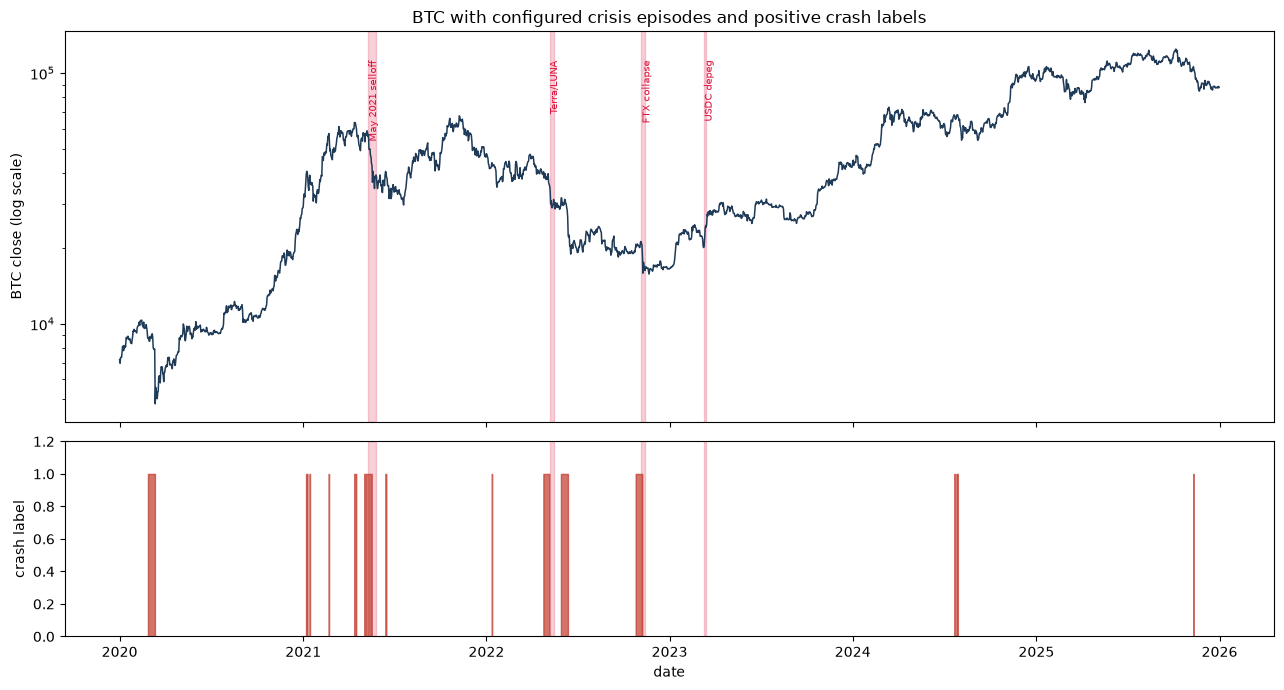

In [4]:
btc = panel.xs('BTC', level='asset')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})
ax1.plot(btc.index, btc['close'], lw=1.1, color='#1f3b57')
ax1.set_yscale('log'); ax1.set_ylabel('BTC close (log scale)')
ax1.set_title('BTC with configured crisis episodes and positive crash labels')

for ep in cfg.episodes:
    for ax in (ax1, ax2):
        ax.axvspan(pd.Timestamp(ep.start, tz='UTC'),
                   pd.Timestamp(ep.end, tz='UTC'), color='crimson', alpha=0.20)
    ax1.text(pd.Timestamp(ep.start, tz='UTC'), btc['close'].max() * 0.9,
             ep.name, rotation=90, fontsize=7, va='top', color='crimson')

ax2.fill_between(btc.index, btc['label'].fillna(0), step='mid',
                 color='#c0392b', alpha=0.7)
ax2.set_ylabel('crash label'); ax2.set_ylim(0, 1.2); ax2.set_xlabel('date')
plt.tight_layout(); plt.show(); plt.close(fig)


## 4. G3 - the seven-model comparison

Leak-free walk-forward with a 45-day embargo. Every model sees identical inputs
through `flatten_windows()`; if they did not, the comparison would not be fair.


In [5]:
comparison = pd.read_csv(cfg.path('tables') / 'model_comparison.csv', index_col=0)
comparison


,pr_auc,f1,precision,recall,false_alarm_rate,brier,pr_auc_baseline,pr_auc_lift,n_test_samples
model,,,,,,,,,
rf,0.170 +/- 0.107,0.126 +/- 0.065,0.221 +/- 0.241,0.194 +/- 0.161,0.099 +/- 0.099,0.114 +/- 0.031,0.0834,0.0864,8292
logreg,0.144 +/- 0.103,0.072 +/- 0.039,0.159 +/- 0.203,0.250 +/- 0.283,0.226 +/- 0.205,0.312 +/- 0.250,0.0834,0.0607,8292
xgb,0.134 +/- 0.037,0.127 +/- 0.071,0.122 +/- 0.049,0.302 +/- 0.189,0.206 +/- 0.152,0.089 +/- 0.040,0.0834,0.0506,8292
lstm,0.102 +/- 0.059,0.100 +/- 0.064,0.071 +/- 0.046,0.363 +/- 0.288,0.365 +/- 0.244,0.177 +/- 0.063,0.0834,0.0182,8292
rule,0.100 +/- 0.052,0.112 +/- 0.066,0.082 +/- 0.042,0.413 +/- 0.335,0.368 +/- 0.251,0.195 +/- 0.060,0.0834,0.0168,8292
gru,0.099 +/- 0.049,0.122 +/- 0.068,0.082 +/- 0.040,0.473 +/- 0.297,0.443 +/- 0.263,0.272 +/- 0.135,0.0834,0.0154,8292
mlp,0.085 +/- 0.040,0.043 +/- 0.029,0.046 +/- 0.045,0.280 +/- 0.417,0.278 +/- 0.394,0.238 +/- 0.146,0.0834,0.0012,8292


In [6]:
per_fold = pd.read_csv(cfg.path('tables') / 'model_comparison_per_fold.csv')
base = per_fold.groupby('fold')['pr_auc_baseline'].first()
print('random-classifier PR-AUC per fold - the number every result must beat:')
print(base.round(3).to_string())
print()
per_fold.pivot(index='model', columns='fold', values='pr_auc').round(3)


random-classifier PR-AUC per fold - the number every result must beat:
fold
fold1_2022    0.151
fold2_2023    0.019
fold3_2024    0.083
fold4_2025    0.081



fold,fold1_2022,fold2_2023,fold3_2024,fold4_2025
model,,,,
gru,0.168,0.029,0.103,0.095
logreg,0.320,0.113,0.083,0.060
lstm,0.191,0.027,0.097,0.092
mlp,0.136,0.028,0.102,0.072
rf,0.335,0.035,0.143,0.166
rule,0.155,0.014,0.117,0.113
xgb,0.178,0.077,0.148,0.133


### Reading the result honestly

**Random Forest wins. The deep models do not.** The one-line volatility rule ties
the from-scratch LSTM and beats the GRU and the MLP.

Spec Rule 12.7 is explicit: *if a simpler model wins, say so; do not tune the deep
model until it wins.* So: on this target, with this feature set, recurrence is not
earning its complexity.

The best model reaches roughly 2x the random baseline, and fold variance is large -
a model that works in 2022 may not work in 2023.

The base paper's F1 of 0.703 is on pin-bar reversals, a far more frequent event.
The numbers are not comparable and we do not claim they are. **Any PR-AUC near 0.95
on this task would be evidence of leakage, not skill.**


## 5. Lead time - the metric that matters operationally

A warning that arrives after the crash has started is not a warning.


In [7]:
lead = pd.read_csv(cfg.path('tables') / 'lead_time.csv')
lead.pivot(index='episode', columns='model', values='lead_time_days')


model,gru,logreg,lstm,mlp,rf,rule,xgb
episode,,,,,,,
FTX collapse,88.0,NaN,90.0,86.0,NaN,-4.0,90.0
May 2021 selloff,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Terra/LUNA,90.0,NaN,21.0,NaN,17.0,NaN,65.0
USDC depeg,90.0,4.0,90.0,NaN,39.0,NaN,88.0


`NaN` means **no sustained warning fired** before that episode. A sustained
crossing requires at least 2 consecutive days above threshold, so single-day noise
does not count as a warning. These failures are reported per episode and never
averaged away.


## 6. G4 - do the same drivers explain every crisis?

The headline research question. The base paper applies SHAP but never tests whether
its explanations are *stable*. An explanation that changes completely between
Terra/LUNA and FTX is not a mechanism; it is a per-episode description dressed up
as one.


In [8]:
consistency = pd.read_csv(cfg.path('tables') / 'attribution_consistency.csv')
spearman = pd.read_csv(cfg.path('tables') / 'attribution_spearman_matrix.csv',
                       index_col=0)
print('stability index:', round(float(consistency['stability_index'].iloc[0]), 3))
print()
print(consistency['interpretation'].iloc[0])
print()
spearman.round(3)


stability index: 0.601

MODERATE consistency: a shared core of drivers recurs, but each episode carries a substantial signature of its own



,May 2021 selloff,Terra/LUNA,FTX collapse,USDC depeg
May 2021 selloff,1.000,0.635,0.677,0.513
Terra/LUNA,0.635,1.000,0.510,0.721
FTX collapse,0.677,0.510,1.000,0.552
USDC depeg,0.513,0.721,0.552,1.000


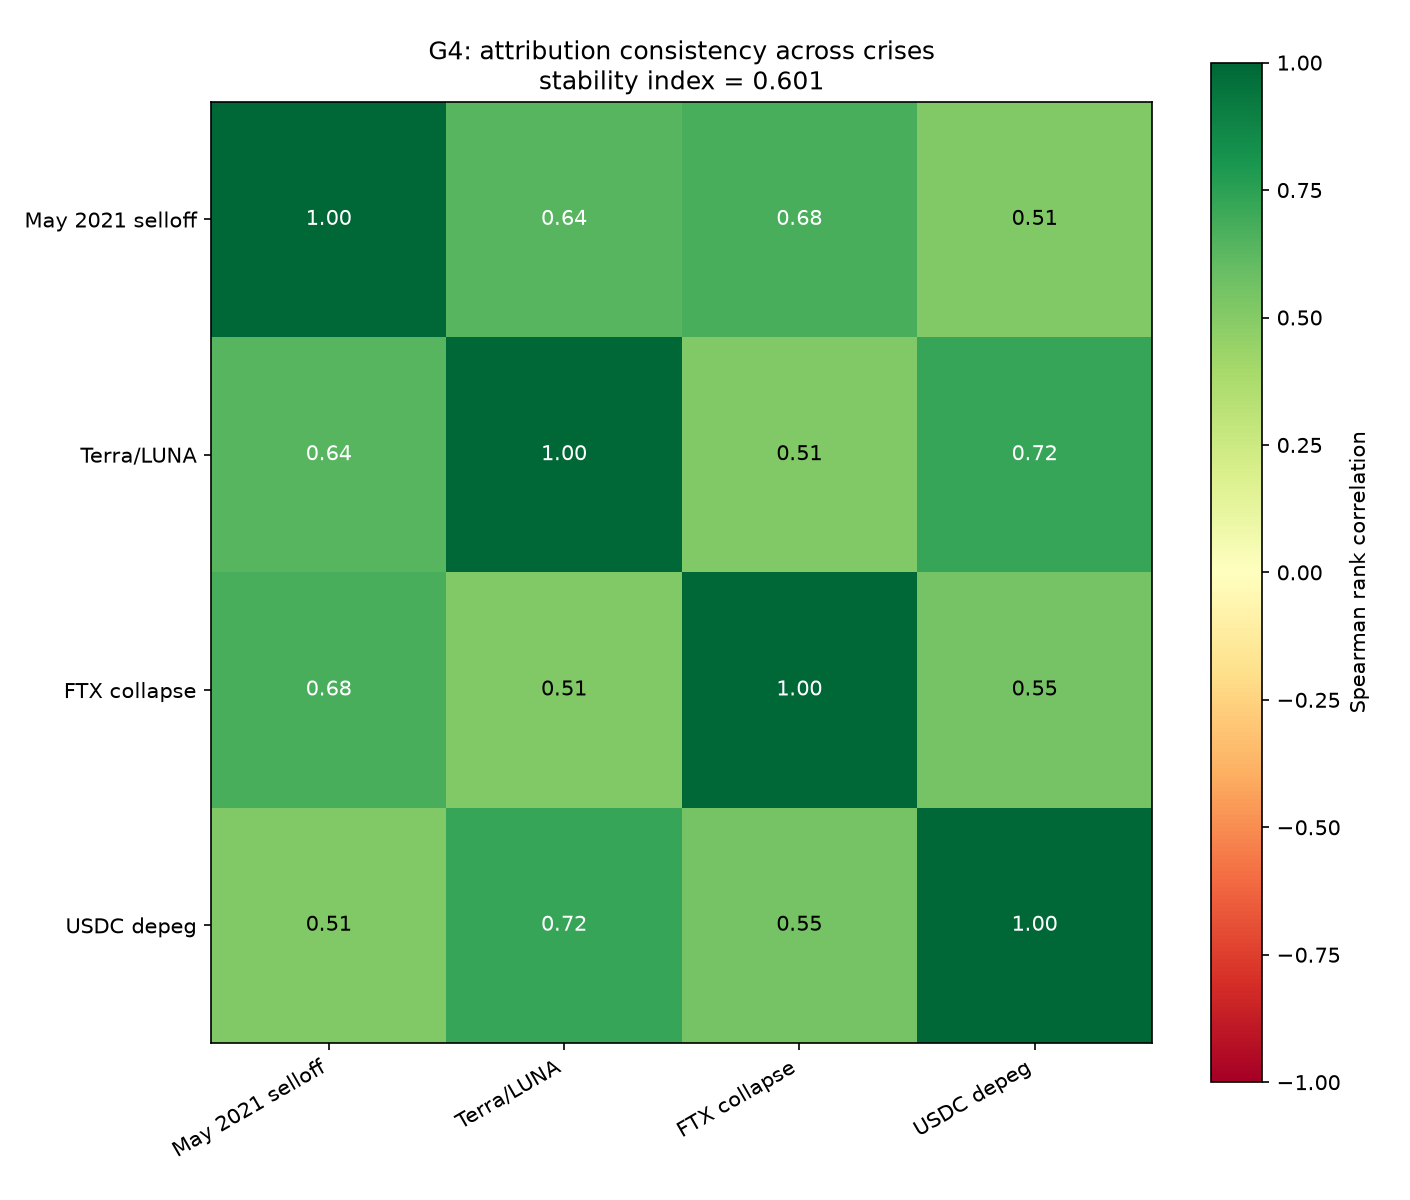

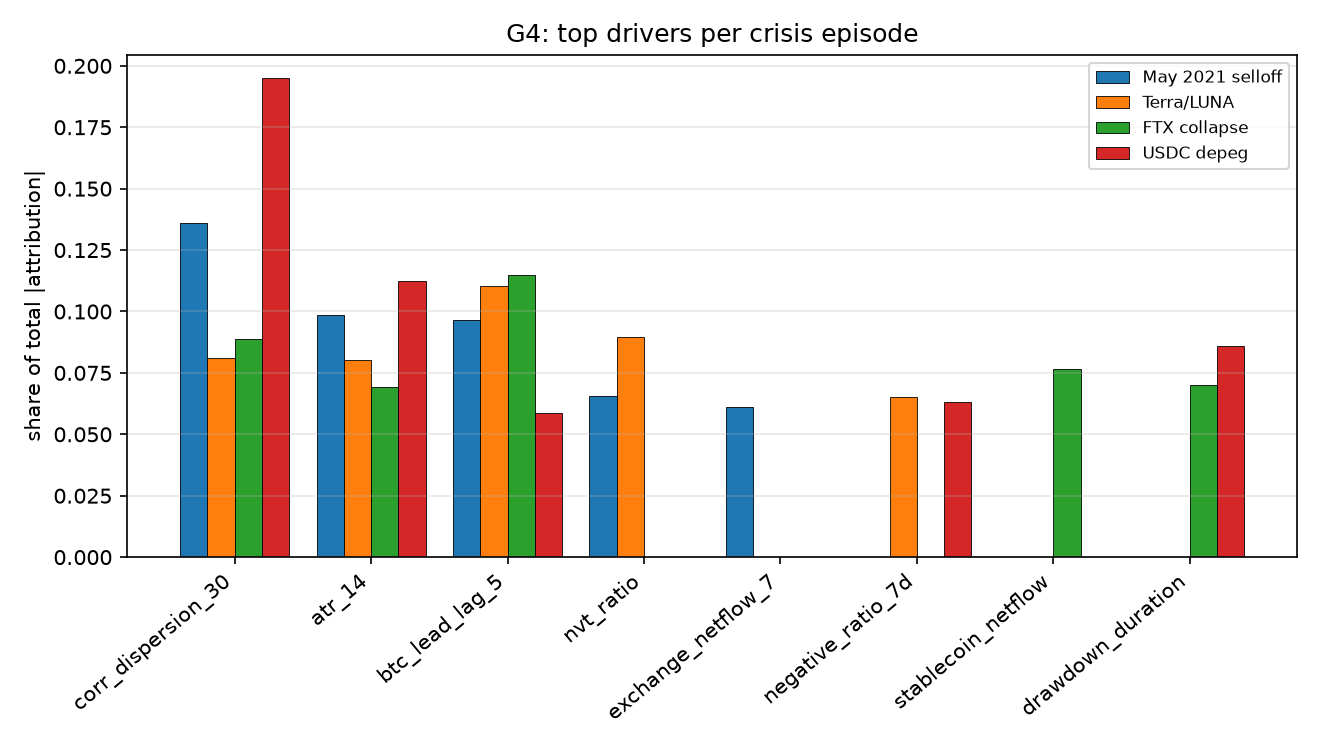

In [9]:
from IPython.display import Image, display
for name in ['attribution_consistency_heatmap.png', 'top_features_per_episode.png']:
    path = cfg.path('figures') / name
    if path.exists():
        display(Image(str(path)))


The interpretation thresholds are fixed in `interpret_stability()` **before** any
result is computed, so the conclusion cannot be retrofitted to whatever number came
out. High consistency would be evidence of a generalisable crash signature; low
consistency is an important negative result bounding how far any
explanation-based crash warning generalises. Both are publishable; only a
fabricated one is not.


## 7. The agent chain - one explained warning

Run on the eve of the FTX collapse. Each agent reports independently, the
orchestrator aggregates, the **skeptic challenges the conclusion**, and only then
is a decision made.


In [10]:
import gc

from bolt.agents.pipeline import ChainGuardPipeline, build_context
from bolt.commands import load_models, load_windows

# The Quantitative Agent runs the CONFIGURED models, not every model in
# the bench. The volatility rule returns an empirical percentile rather
# than a calibrated probability, so including it manufactures
# 'disagreement' that means nothing.
quant_models = list(cfg.section('agents')['quant_models'])
try:
    models, scaler = load_models(cfg, quant_models)
    print('quantitative agent using:', sorted(models))
except FileNotFoundError as exc:
    models, scaler = {}, None
    print('no trained models -', exc)

# Supplying the analogue source activates the Skeptic's precedent check;
# without it that challenge silently never fires.
#
# Subset to the demo asset immediately and release the rest. The full
# tensor is 62 MB and this notebook only ever looks at BTC, so holding
# all ten assets just to read one is what made the kernel run out of
# memory on a busy machine.
ASSET = 'BTC'
_X, _, _meta = load_windows(cfg)
_keep = (_meta['asset'] == ASSET).to_numpy()
X_all = _X[_keep].copy()
meta_all = _meta[_keep].reset_index(drop=True)
del _X, _meta, _keep
gc.collect()
print(f'windows for {ASSET}: {X_all.shape}  ({X_all.nbytes/1e6:.0f} MB)')

analogue_source = (X_all, meta_all, panel['close'])
print()

ctx = build_context(cfg, panel, 'BTC', pd.Timestamp('2022-11-05'),
                    list(cfg.feature_columns))
pipeline = ChainGuardPipeline(cfg, models, scaler,
                              analogue_source=analogue_source)
result = pipeline.run(ctx, commit=False)
print(result.render())


quantitative agent using: ['lstm', 'xgb']


windows for BTC: (2083, 30, 21)  (10 MB)



Market Intelligence Agent
  Risk: LOW  (31/100)
  Evidence:
    v 30-day volatility is calm: 0.3181, 3% of its trailing history
    v average true range is calm: 0.03085, 7% of its trailing history
    ^ drawdown from the running peak is elevated: 0.6846, 91% of its trailing history
    v relative strength is calm: 65.41, 16% of its trailing history
    v short-horizon volatility is calm: 0.3852, 17% of its trailing history
  Confidence: 43%

On-Chain Intelligence Agent
  Risk: MODERATE  (53/100)
  Status: DEGRADED
  Evidence:
    v valuation relative to turnover is benign: -12.61, 2% of history
    ^ network activity (proxy) is elevated: 15.53, 94% of its trailing history
    ^ stablecoin supply growth is elevated: -0.0001764, 81% of its trailing history
  Note: 4 of 5 inputs are DOCUMENTED PROXIES, not direct ledger reads (active_addresses, exchange_netflow_7, nvt_ratio, whale_tx_count). No Etherscan key is configured; see data/processed/DATA_CARD.md for what each stands in for.
  Co

> ### WARNING - these dates are IN-SAMPLE
>
> `bolt train` fits the deployment models on every window whose label resolves
> before 2024-11-17, so 2022-11-05 is **inside the training data**. What this cell
> demonstrates is that the agent chain wires together correctly and produces a
> coherent, explained decision - *not* that the system predicted FTX.
>
> Presenting an in-sample hit as foresight is precisely the hindsight fitting that
> G5 exists to make impossible. The honest out-of-sample evidence is the
> walk-forward table in section 4.

Note the **Skeptic Agent**. It is not decoration: its counter-evidence lowers the
final confidence, and when confidence falls below the floor the Decision Agent
returns `INSUFFICIENT_EVIDENCE` rather than issuing a warning it cannot support.

Note also which agents mark themselves `DEGRADED` and why - the On-Chain agent
declares that four of its five inputs are documented proxies, and the News agent
declares that event identification is not implemented.


## 8. The historical analogue

*When did the market last look like this, and what happened next?*

`exclude_days` is load-bearing: consecutive 30-day windows share 29 days of data,
so without it the nearest neighbours of today are yesterday and the day before.
A window from last week is not a historical precedent.


In [11]:
from bolt.explain.analogue import nearest_historical_analogue
from bolt.windows import flatten_windows

# Reuse the tensor loaded above rather than reading it again. Two copies
# of a 59 MiB array is enough to abort the kernel on a busy machine.
# X_all is already the demo asset only, loaded above.
flat = flatten_windows(X_all)
sub_meta = meta_all

ends = pd.to_datetime(sub_meta['window_end'], utc=True)
target = int(np.flatnonzero(ends <= pd.Timestamp('2022-11-05', tz='UTC'))[-1])

analogues = nearest_historical_analogue(
    flat[target], flat, sub_meta, prices=panel['close'], k=3,
    exclude_days=90, as_of=pd.Timestamp('2022-11-05', tz='UTC'))

for a in analogues:
    o = a['what_happened_next_30d']
    outcome = (f"{o['max_drawdown']:.1%} drawdown" if o.get('available')
               else 'outcome unavailable')
    print(f"{a['date']}  similarity {a['similarity']:.3f}  -> next 30d: {outcome}")

del flat
print()
print('exclude_days=90 is why none of these is from the same week: consecutive')
print('30-day windows share 29 days of data, so an adjacent window is the same')
print('observation rather than a precedent.')


2022-07-30  similarity 0.543  -> next 30d: 17.3% drawdown
2022-07-31  similarity 0.540  -> next 30d: 16.0% drawdown
2023-03-19  similarity 0.540  -> next 30d: 3.0% drawdown

exclude_days=90 is why none of these is from the same week: consecutive
30-day windows share 29 days of data, so an adjacent window is the same
observation rather than a precedent.


## 9. G5 - the on-chain proof

The strongest and most original claim. Every predictive paper in this field - the
base paper included - asks the reader to trust a backtest that could in principle
have been tuned after the fact, and nothing in the published record distinguishes
genuine foresight from hindsight fitting. A cryptographic commitment on a public
ledger is the only mechanism that resolves this.


In [12]:
payload = result.commitment.prediction.canonical()
print('canonical payload - the exact bytes a verifier hashes:')
print(payload[:420].decode(), '...')
print()
print('prediction id :', result.commitment.prediction.prediction_id)
print('sha-256       :', result.commitment.digest)
print('payload file  :', result.commitment.payload_path)


canonical payload - the exact bytes a verifier hashes:
{"agent_reports":[{"agent":"Market Intelligence Agent","confidence":0.434862,"evidence":[{"detail":"30-day volatility is calm: 0.3181, 3% of its trailing history","direction":-1,"name":"realized_vol_30","value":0.318112,"weight":0.972277},{"detail":"average true range is calm: 0.03085, 7% of its trailing history","direction":-1,"name":"atr_14","value":0.03085,"weight":0.927945},{"detail":"drawdown from the running pe ...

prediction id : 0x124ecfa5953bf81e23854577b0e654ee9096a4d93b5bd7a646968e3f0e7c1f93
sha-256       : 0x29b2ee74e8a01d52db230d7a0b9f9de57c594149916ba5251397fefcf1d91fe9
payload file  : D:\Capstone\outputs\predictions\0x124ecfa5953bf81e.json


In [13]:
# Determinism: shuffling the dict must not change the digest.
from bolt.chain.payload import canonical_payload, digest_hex

original = result.commitment.prediction.to_dict()
shuffled = {k: original[k] for k in reversed(list(original))}

print('key order      :', list(original)[:3], 'vs', list(shuffled)[:3])
print('same digest    :',
      digest_hex(canonical_payload(original)) == digest_hex(canonical_payload(shuffled)))
print()
print('A verifier recomputing this hash on another machine gets the same result,')
print('which is what makes a mismatch mean tampering rather than noise.')


key order      : ['prediction_id', 'asset', 'as_of_date'] vs ['expected_severity', 'counter_evidence', 'agent_reports']
same digest    : True

A verifier recomputing this hash on another machine gets the same result,
which is what makes a mismatch mean tampering rather than noise.


### Independent verification

```bash
bolt verify --payload outputs/predictions/<id>.json --id <prediction_id>
```

`chain/verify.py` re-implements canonicalisation from the standard library and is
**tested to import nothing from the pipeline it verifies** - verification that
depends on the system it verifies proves nothing.

The contract's overwrite revert is what the whole claim rests on, and it is tested
against a real compiled EVM in `tests/test_contract.py`: nobody, *including the
original committer*, can replace a commitment once it is made.


## Summary

| Contribution | Status |
|---|---|
| G1 economically meaningful target | done, with a published sensitivity table |
| G2 cross-asset contagion features | done, correlation graph + eigenvector centrality |
| G3 seven-model fair comparison | done - RF wins, deep models do not, reported as found |
| G4 attribution consistency across crises | done, thresholds fixed in advance |
| G5 on-chain commitment | contract and payload tested; testnet deploy pending |

**What has actually been built:** a reproducible pipeline from public APIs to a
leak-free evaluated model comparison, with cross-episode attribution consistency,
a multi-agent evidence layer that challenges its own predictions, and a
cryptographic commitment scheme that makes the track record auditable.

**What has not:** the LLM narrative backend and news event identification
(Phase 7), and a live testnet deployment, which needs a funded Amoy key.
